In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("data/Training.csv")
test = pd.read_csv("data/Testing.csv")

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [5]:
print("Training Shape:", train.shape)
print("Testing Shape:", test.shape)

Training Shape: (4920, 134)
Testing Shape: (42, 133)


In [6]:
train.columns

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='object', length=134)

In [7]:
if 'Unnamed: 133' in train.columns:
    train.drop('Unnamed: 133', axis=1, inplace=True)

if 'Unnamed: 133' in test.columns:
    test.drop('Unnamed: 133', axis=1, inplace=True)

In [8]:
X_train = train.drop('prognosis', axis=1)
y_train = train['prognosis']

X_test = test.drop('prognosis', axis=1)
y_test = test['prognosis']

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train_encoded)

RandomForestClassifier(random_state=42)

In [11]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test_encoded,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9761904761904762


In [12]:
train.head()
print(train.shape)

(4920, 133)


In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train_encoded)

print("Model trained successfully!")

Model trained successfully!


In [15]:
predictions = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test_encoded,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9761904761904762


In [17]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample)

predicted_disease = encoder.inverse_transform(prediction)

print("Predicted Disease:", predicted_disease[0])
print("Actual Disease:", y_test.iloc[0])

Predicted Disease: Fungal infection
Actual Disease: Fungal infection


C:\Users\PRIYANSHI PATEL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [18]:
medicine_dict = {
    "Fungal infection": "Clotrimazole Cream",
    "Allergy": "Cetirizine",
    "GERD": "Omeprazole",
    "Chronic cholestasis": "Ursodeoxycholic Acid",
    "Drug Reaction": "Antihistamines",
    "Peptic ulcer disease": "Pantoprazole",
    "AIDS": "Consult Specialist",
    "Diabetes": "Metformin",
    "Hypertension": "Amlodipine",
    "Migraine": "Paracetamol",
    "Common Cold": "Paracetamol + Rest",
    "Pneumonia": "Consult Doctor"
}

In [19]:
medicine = medicine_dict.get(
    predicted_disease[0],
    "Consult Doctor"
)

print("Recommended Medicine:", medicine)

Recommended Medicine: Clotrimazole Cream


In [20]:
symptoms = X_train.columns.tolist()

input_symptoms = ['itching', 'skin_rash']

user_input = [0] * len(symptoms)

for symptom in input_symptoms:
    if symptom in symptoms:
        user_input[symptoms.index(symptom)] = 1

prediction = model.predict([user_input])

disease = encoder.inverse_transform(prediction)

print("Predicted Disease:", disease[0])

Predicted Disease: Fungal infection


C:\Users\PRIYANSHI PATEL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
def predict_disease(symptom_list):
    
    symptoms = X_train.columns.tolist()
    
    input_data = [0] * len(symptoms)
    
    for symptom in symptom_list:
        if symptom in symptoms:
            input_data[symptoms.index(symptom)] = 1
    
    prediction = model.predict([input_data])
    
    disease = encoder.inverse_transform(prediction)
    
    return disease[0]

In [22]:
user_symptoms = [
    'itching',
    'skin_rash',
    'nodal_skin_eruptions'
]

disease = predict_disease(user_symptoms)

print("Predicted Disease:", disease)

Predicted Disease: Fungal infection


C:\Users\PRIYANSHI PATEL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
medicine_dict = {
    "Fungal infection": {
        "medicine": "Clotrimazole Cream",
        "precaution": "Keep affected area dry",
        "diet": "Avoid oily foods"
    },

    "Allergy": {
        "medicine": "Cetirizine",
        "precaution": "Avoid allergens",
        "diet": "Drink plenty of water"
    },

    "GERD": {
        "medicine": "Omeprazole",
        "precaution": "Avoid spicy food",
        "diet": "Low acid diet"
    },

    "Migraine": {
        "medicine": "Paracetamol",
        "precaution": "Avoid stress",
        "diet": "Stay hydrated"
    }
}

In [24]:
recommendation = medicine_dict.get(
    disease,
    {
        "medicine": "Consult Doctor",
        "precaution": "Consult Doctor",
        "diet": "Balanced Diet"
    }
)

print("Disease:", disease)
print("Medicine:", recommendation["medicine"])
print("Precaution:", recommendation["precaution"])
print("Diet:", recommendation["diet"])

Disease: Fungal infection
Medicine: Clotrimazole Cream
Precaution: Keep affected area dry
Diet: Avoid oily foods


In [26]:
symptoms_input = input(
    "Enter symptoms separated by commas: "
)

user_symptoms = symptoms_input.split(",")

user_symptoms = [
    symptom.strip()
    for symptom in user_symptoms
]

disease = predict_disease(user_symptoms)

recommendation = medicine_dict.get(
    disease,
    {
        "medicine": "Consult Doctor",
        "precaution": "Consult Doctor",
        "diet": "Balanced Diet"
    }
)

print("\nPredicted Disease:", disease)
print("Recommended Medicine:", recommendation["medicine"])
print("Precaution:", recommendation["precaution"])
print("Diet Recommendation:", recommendation["diet"])

Enter symptoms separated by commas:  itching



Predicted Disease: Fungal infection
Recommended Medicine: Clotrimazole Cream
Precaution: Keep affected area dry
Diet Recommendation: Avoid oily foods


C:\Users\PRIYANSHI PATEL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


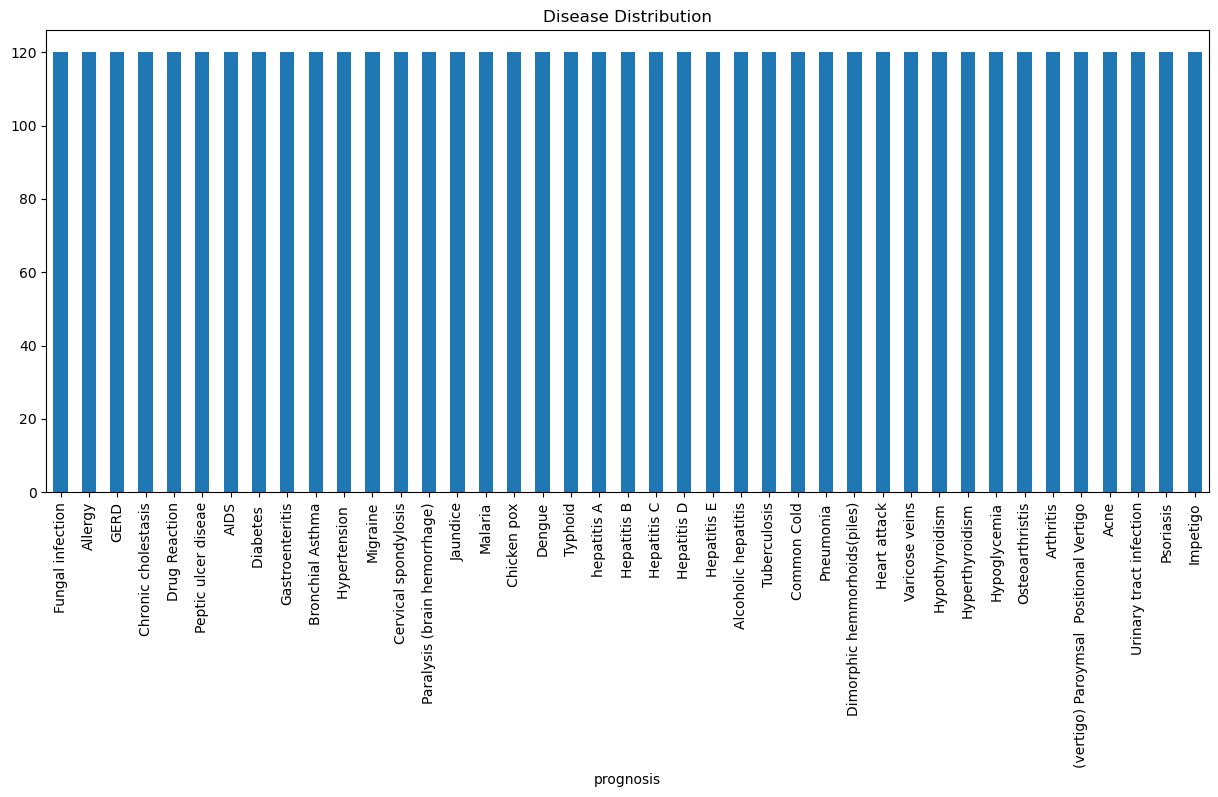

In [27]:
import matplotlib.pyplot as plt

train['prognosis'].value_counts().plot(
    kind='bar',
    figsize=(15,6)
)

plt.xticks(rotation=90)
plt.title("Disease Distribution")
plt.show()

In [28]:
import joblib

joblib.dump(model, "disease_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, predictions)

print(cm)

[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    predictions,
    target_names=encoder.classes_
))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

In [31]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Symptom': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Symptom,Importance
97,muscle_pain,0.019439
0,itching,0.016014
98,altered_sensorium,0.016001
33,dark_urine,0.015811
25,high_fever,0.015623
41,mild_fever,0.015100
106,family_history,0.014786
34,nausea,0.014670
43,yellowing_of_eyes,0.014079
28,sweating,0.013823


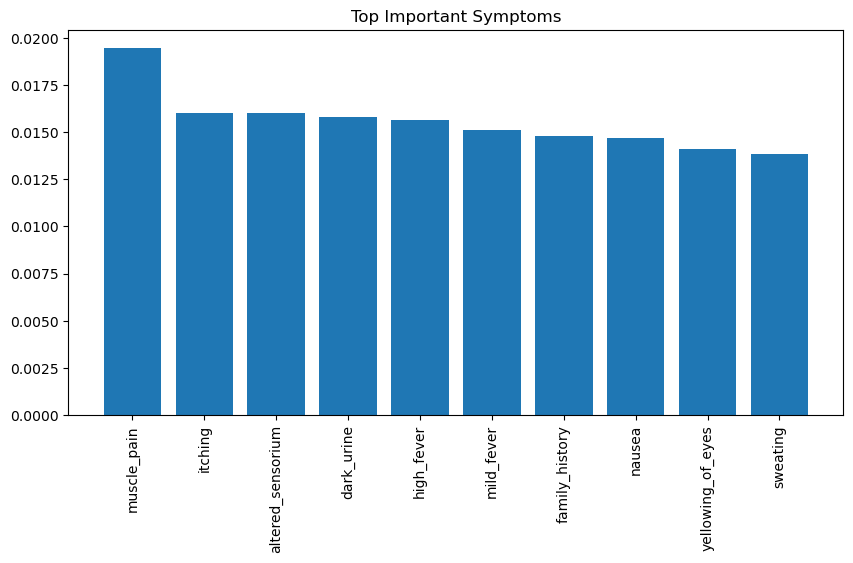

In [32]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_features['Symptom'],
    top_features['Importance']
)

plt.xticks(rotation=90)

plt.title("Top Important Symptoms")
plt.show()

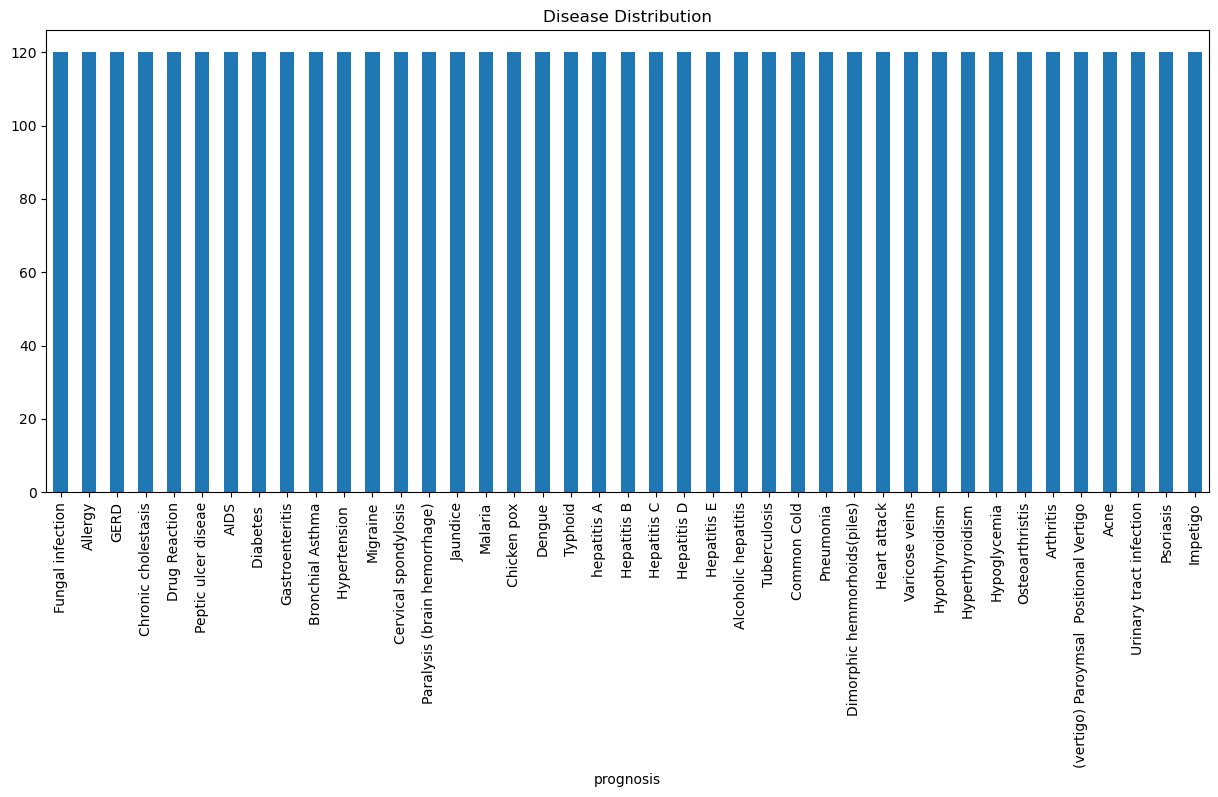

In [33]:
train['prognosis'].value_counts().plot(
    kind='bar',
    figsize=(15,6)
)

plt.xticks(rotation=90)
plt.title("Disease Distribution")
plt.show()

In [34]:
import joblib

joblib.dump(model, "disease_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']